In [1]:
# %pip install --upgrade plotly

In [15]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import datetime as dt
from scipy.stats import gaussian_kde


# This might be helpful:
from collections import Counter

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

In [4]:
df = pd.read_csv('2026-06-25-washington-post-police-shootings-export.csv')

# Fatal Force in America: A Data Analysis of Washington Post's Police Shooting Records (2015–2024)

## Preliminary Data Exploration

.shape, the number of colums and rows, and column titles

In [5]:
# df.shape
print(f'Columns: {df.shape[1]}\nRows: {df.shape[0]}')
print(f'Column titles: {df.columns}')

Columns: 12
Rows: 10430
Column titles: Index(['date', 'name', 'age', 'gender', 'armed', 'race', 'city', 'state',
       'flee', 'body_camera', 'signs_of_mental_illness',
       'police_departments_involved'],
      dtype='str')


In [6]:
# df.isnull().sum()

In [7]:
# df.duplicated().sum()

## Dataset Sample

In [8]:
def swap_nans_with_zero(dataframe):
    """Replace missing/NaN values in text columns with 'Unknown'"""
    for col in dataframe.columns:
        if dataframe[col].dtype == 'object':
            dataframe[col] = dataframe[col].fillna('Unknown')
            dataframe[col] = dataframe[col].replace('NaN', 'Unknown')
    return dataframe

swap_nans_with_zero(df)

,date,name,age,gender,armed,race,city,state,flee,body_camera,signs_of_mental_illness,police_departments_involved
0,2015-01-02,Lewis Lee Lembke,47.00,male,gun,White,Aloha,OR,not,False,False,"Washington County Sheriff's Office, OR"
1,2015-01-02,Tim Elliot,53.00,male,gun,Asian,Shelton,WA,not,False,True,"Mason County Sheriff's Office, WA"
2,2015-01-03,John Paul Quintero,23.00,male,unarmed,Hispanic,Wichita,KS,not,False,False,"Wichita Police Department, KS"
3,2015-01-04,Kenneth Joe Brown,18.00,male,gun,White,Guthrie,OK,not,False,False,"Oklahoma Highway Patrol, OK"
4,2015-01-04,Michael Rodriguez,39.00,male,other,Hispanic,Evans,CO,not,False,False,"Evans Police Department, CO"
...,...,...,...,...,...,...,...,...,...,...,...,...
10425,2024-12-30,Timothy Woods,26.00,male,gun,Black,Orlando,FL,foot,False,False,"Orlando Police Department, FL"
10426,2024-12-30,NaN,38.00,male,knife,Unknown,Sacramento,CA,NaN,True,True,"Sacramento County Sheriff's Department, CA"
10427,2024-12-30,Kenneth Thaddeus Roberts Jr.,48.00,male,gun,Black,Indianapolis,IN,car,False,False,"Indianapolis Metropolitan Police Department, I..."
10428,2024-12-31,Moses Alik,22.00,male,knife,Unknown,Celina,OH,NaN,False,False,"Mercer County Sheriff's Office, OH"


## Find out a trend in the police killing over time (2015 - 2014)

In [9]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df_monthly = df.groupby(['year', 'month']).size().reset_index(name='count')
df_monthly['year_month'] = pd.to_datetime(df_monthly[['year', 'month']].assign(day=1))
# print(df_monthly)

Trend slope : +0.158 deaths/month
Overall mean: 86.9 deaths/month
Highest month: May 2024 (126 deaths)
Lowest month : Sep 2018 (59 deaths)


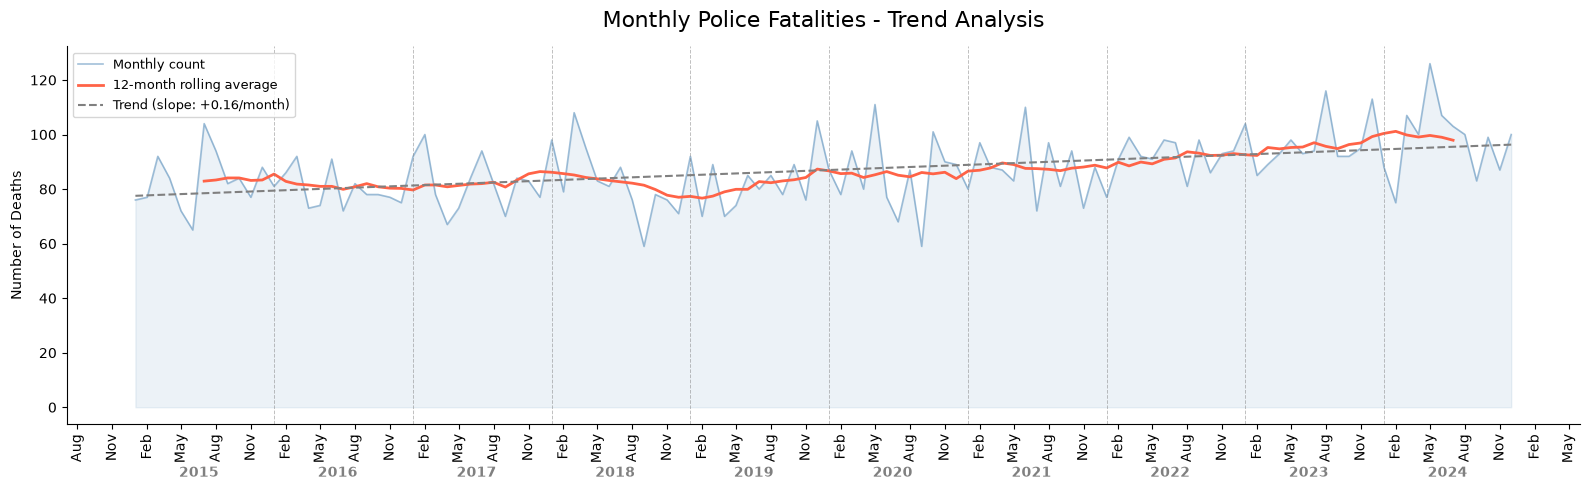

In [10]:
import matplotlib.dates as mdates

df_monthly['x_idx'] = range(len(df_monthly))

z = np.polyfit(df_monthly['x_idx'], df_monthly['count'], 1)
p = np.poly1d(z)
trend = p(df_monthly['x_idx'])

df_monthly['rolling_12'] = df_monthly['count'].rolling(window=12, center=True).mean()

fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(
    df_monthly['year_month'],
    df_monthly['count'],
    color='steelblue',
    linewidth=1.2,
    alpha=0.5,
    label='Monthly count'
    )
ax.fill_between(
    df_monthly['year_month'],
    df_monthly['count'],
    alpha=0.1, 
    color='steelblue'
)

ax.plot(
    df_monthly['year_month'], 
    df_monthly['rolling_12'],
    color='tomato',
    linewidth=2,
    label='12-month rolling average'
)

ax.plot(
    df_monthly['year_month'],
    trend,
    color='grey',
    linewidth=1.5,
    linestyle='--',
    label=f'Trend (slope: {z[0]:+.2f}/month)'
    )

ax.set_title(
    'Monthly Police Fatalities - Trend Analysis',
    fontsize=16,
    pad=14
    )
ax.set_xlabel('')
ax.set_ylabel('Number of Deaths')
ax.legend(fontsize=9)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.tick_params(axis='x', rotation=90)
ax.spines[['top', 'right']].set_visible(False)

years = df_monthly['year'].unique()
for year in sorted(years):
    year_start = pd.Timestamp(f'{year}-01-01')
    year_end   = pd.Timestamp(f'{year}-12-01')
    year_mid   = year_start + (year_end - year_start) / 2
    if year != min(years):
        ax.axvline(x=year_start, color='grey', linewidth=0.7,
                   linestyle='--', alpha=0.5)
    ax.annotate(
        str(year),
        xy=(year_mid, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(0, -30),
        textcoords='offset points',
        ha='center', va='top',
        fontsize=10, fontweight='bold', color='grey'
    )

# ── Print trend summary ────────────────────────────────────────────────
print(f"Trend slope : {z[0]:+.3f} deaths/month")
print(f"Overall mean: {df_monthly['count'].mean():.1f} deaths/month")
print(f"Highest month: {df_monthly.loc[df_monthly['count'].idxmax(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].max()} deaths)")
print(f"Lowest month : {df_monthly.loc[df_monthly['count'].idxmin(), 'year_month'].strftime('%b %Y')} "
      f"({df_monthly['count'].min()} deaths)")

plt.tight_layout()
plt.show()



## Gender Breakdown of US Police Fatalities

In [11]:
df_gender = df.groupby(['gender']).size().reset_index(name='count')
gender_map = {
    'female': 'Female',
    'male' : 'Male',
    'non-binary' : 'Non-binary'
}
df_gender['gender_name'] = df_gender['gender'].map(gender_map)
df_gender = df_gender.sort_values('count', ascending=False)

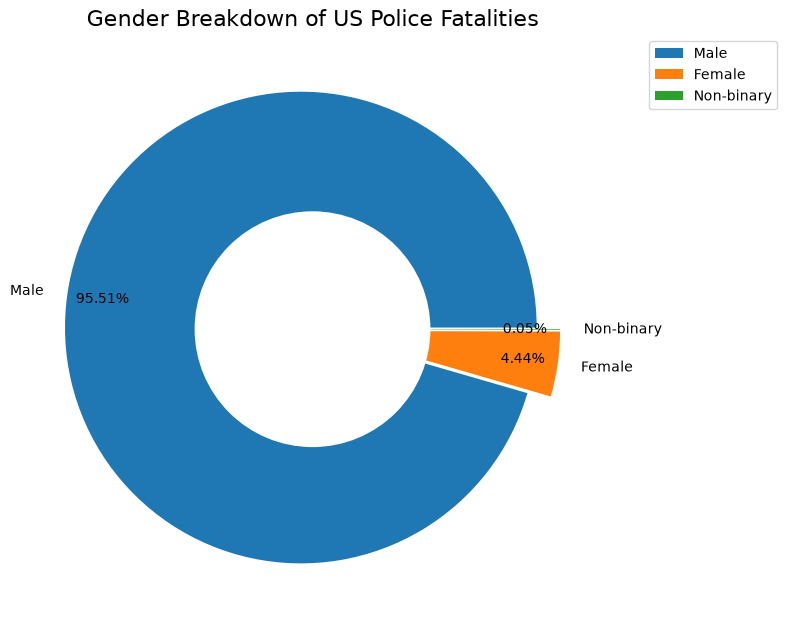

In [12]:
explode = [0.05] * len(df_gender)

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    df_gender['count'],
    labels=df_gender['gender_name'],
    autopct='%1.2f%%',
    pctdistance=0.85,
    explode=explode
)
centre_circle = plt.Circle((0,0), 0.50, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    "Gender Breakdown of US Police Fatalities",
    fontsize=16,
    fontfamily='DejaVu Sans'
)
plt.legend(
    labels=df_gender['gender_name'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)
)
plt.tight_layout()
plt.show()


## Age Distribution of Police Fatalities by Gender - case numbers

In [13]:
bins = [0, 18, 25, 35, 45, 55, 65, 100]
age_labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=age_labels)
df_gender_age = df.groupby(['gender', 'age_group']).size().reset_index(name='count')
df_gender_age['gender_name'] = df_gender_age['gender'].map(gender_map).fillna('Unknown')
# print(df_gender_age)

In [14]:
import plotly.graph_objects as go

male_data = df_gender_age[df_gender_age['gender'] == 'male']
female_data = df_gender_age[df_gender_age['gender'] == 'female']
non_binary_data = df_gender_age[df_gender_age['gender'] == 'non-binary']

fig = go.Figure()

fig.add_trace(go.Bar(
    x=male_data['age_group'].astype(str),
    y=male_data['count'],
    name='Male',
    marker_color='steelblue'
))

fig.add_trace(go.Bar(
    x=female_data['age_group'].astype(str),
    y=female_data['count'],
    name='Female',
    marker_color='tomato'
))

fig.update_layout(
    barmode='group',
    title='Age Distribution of Fatal Police Encounters by Gender (2015–2024)',
    xaxis_title='Age Group',
    yaxis_title='Number of Deaths',
    template='simple_white',
    legend_title='Gender'
)
fig.show()

### Age Distribution by Gender

In [21]:
male = df[df['gender'] == 'male']

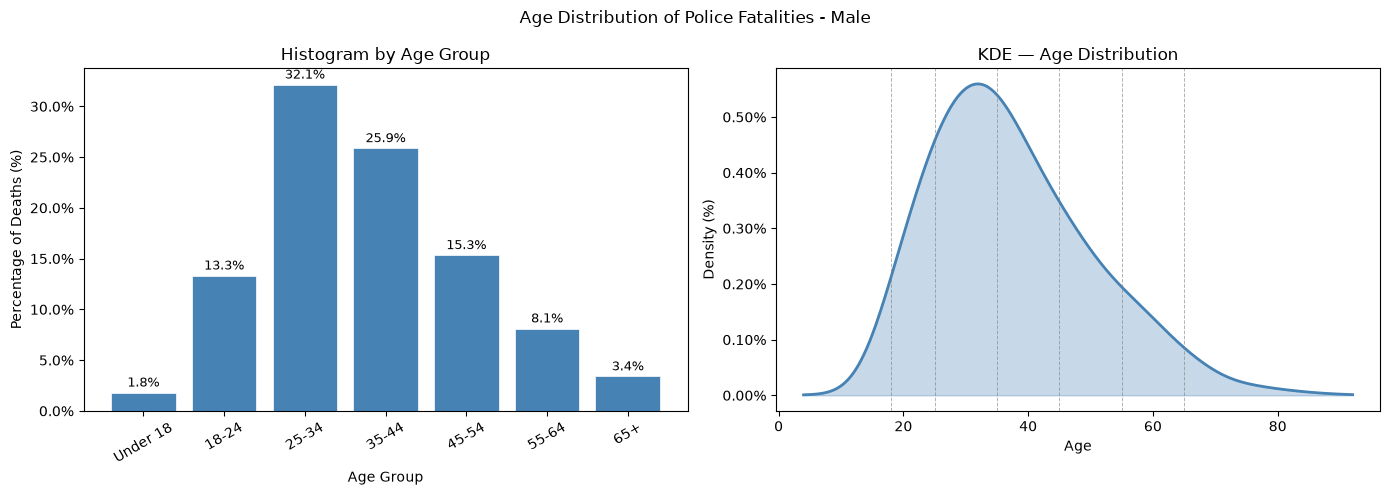

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution of Police Fatalities - Male')
# ── Left: Histogram ────────────────────────────────────────────────────
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

ages = male['age'].dropna()
total = len(ages)

counts, edges = np.histogram(ages, bins=bins)
percentages = (counts / total) * 100

bars = axes[0].bar(labels, percentages, color='steelblue', edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bar, pct in zip(bars, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Histogram by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage of Deaths (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=30)

# ── Right: KDE ─────────────────────────────────────────────────────────
kde = gaussian_kde(ages, bw_method=0.3)
x = np.linspace(ages.min(), ages.max(), 500)
y = kde(x)
y_pct = (y / y.sum()) * 100

axes[1].plot(x, y_pct, color='steelblue', linewidth=2)
axes[1].fill_between(x, y_pct, alpha=0.3, color='steelblue')

# Add vertical lines for age group boundaries
for boundary in [18, 25, 35, 45, 55, 65]:
    axes[1].axvline(x=boundary, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)

axes[1].set_title('KDE — Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

In [24]:
female = df[df['gender'] == 'female']

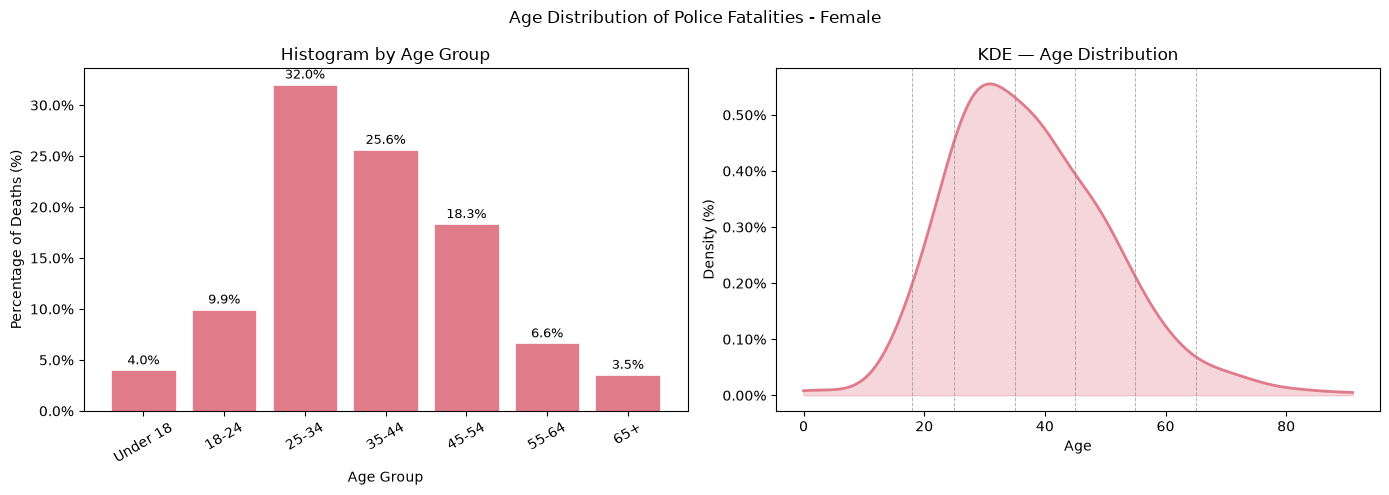

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Age Distribution of Police Fatalities - Female')
# ── Left: Histogram ────────────────────────────────────────────────────
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']

ages = female['age'].dropna()
total = len(ages)

counts, edges = np.histogram(ages, bins=bins)
percentages = (counts / total) * 100

bars = axes[0].bar(labels, percentages, color='#E07B8A', edgecolor='white', linewidth=0.5)

# Add percentage labels on top of each bar
for bar, pct in zip(bars, percentages):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=9
    )

axes[0].set_title('Histogram by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Percentage of Deaths (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=30)

# ── Right: KDE ─────────────────────────────────────────────────────────
kde = gaussian_kde(ages, bw_method=0.3)
x = np.linspace(ages.min(), ages.max(), 500)
y = kde(x)
y_pct = (y / y.sum()) * 100

axes[1].plot(x, y_pct, color='#E07B8A', linewidth=2)
axes[1].fill_between(x, y_pct, alpha=0.3, color='#E07B8A')

# Add vertical lines for age group boundaries
for boundary in [18, 25, 35, 45, 55, 65]:
    axes[1].axvline(x=boundary, color='grey', linestyle='--', linewidth=0.7, alpha=0.6)

axes[1].set_title('KDE — Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Density (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

### Racial Breakdown of Police Shooting Fatalities 

In [56]:
df['race'] = df['race'].apply(lambda x: 'Mixed' if ',' in str(x) else x)
races = df.groupby(['race']).size().reset_index(name='count').sort_values('count', ascending=False)

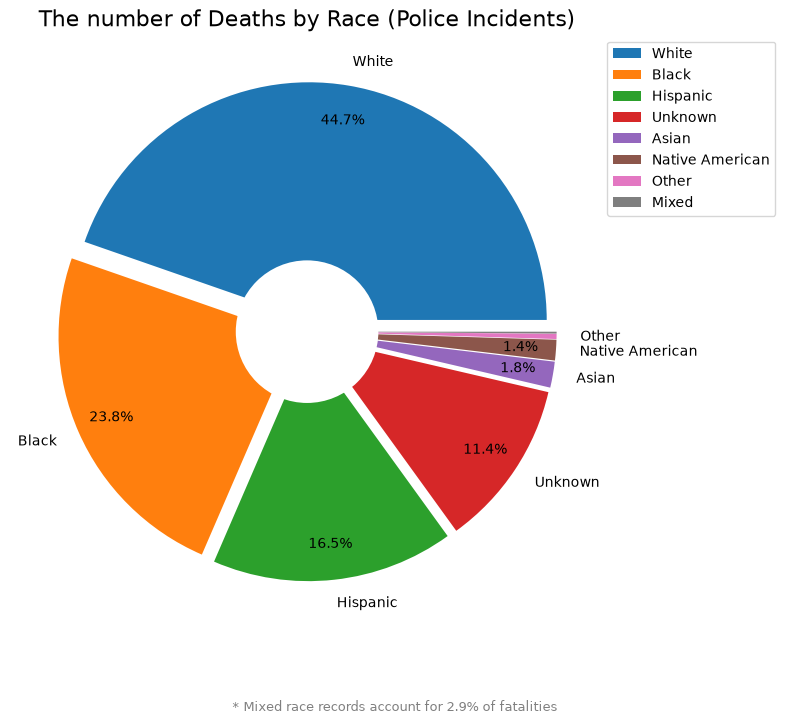

In [ ]:
explode = [0.05] * len(races)

fig, ax = plt.subplots(figsize=(8, 8))

labels = [r if c/total > 0.04 else '' for r, c in zip(races['race'], races['count'])]
mixed_pct = races[races['race'] == 'Mixed']['count'].sum() / total * 100

def autopct_filter(pct):
    return f'{pct:.1f}%' if pct > 0.3 else ''

ax.pie(
    races['count'],
    labels=labels,
    autopct=autopct_filter,
    pctdistance=0.85,
    explode=explode
)
centre_circle = plt.Circle((0,0), 0.30, fc='white')
ax.add_artist(centre_circle)
ax.set_title(
    'The number of Deaths by Race (Police Incidents)',
    fontsize=16,
    fontfamily='DejaVu Sans'
)
fig.text(0.5, 0.01, f'* Mixed race records account for {mixed_pct:.1f}% of fatalities',
         ha='center', fontsize=9, color='grey')
plt.legend(
    labels=races['race'],
    loc='upper right',
    bbox_to_anchor=(1.3, 1)
)
plt.tight_layout()
plt.show()

### Which state has more risks of facing police shooting incidents?

In [34]:
import plotly.express as px

# Group by state for choropleths
incidents_by_state = df.groupby('state').size().reset_index(name='count').sort_values('count', ascending=False)

fig = px.choropleth(
    incidents_by_state,
    locations='state',
    locationmode='USA-states',
    color='count',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    title='Average Poverty Rate by US State',
    labels={'avg_poverty_rate': 'Avg Poverty Rate (%)'}
)

fig.update_layout(
    geo=dict(showlakes=True, lakecolor='LightBlue'),
    title_x=0.5
)

fig.show()

### Police Shooting Fatalities Across US Cities

In [41]:
incidents_by_city = df.groupby(['city', 'state']).size().reset_index(name='count').sort_values('count', ascending=True)

geo = pd.read_csv('https://raw.githubusercontent.com/kelvins/US-Cities-Database/main/csv/us_cities.csv')
# has CITY, STATE_CODE, LATITUDE, LONGITUDE columns

incidents_by_city = incidents_by_city.merge(
    geo[['CITY', 'STATE_CODE', 'LATITUDE', 'LONGITUDE']],
    left_on=['city', 'state'],
    right_on=['CITY', 'STATE_CODE'],
    how='left'
).rename(columns={'LATITUDE': 'lat', 'LONGITUDE': 'lon'})

In [43]:
import plotly.express as px

fig = px.scatter_mapbox(
    incidents_by_city,
    lat='lat',
    lon='lon',
    size='count',
    hover_name='city',
    hover_data={'count': True, 'lat': False, 'lon': False},
    color='count',
    color_continuous_scale='Reds',
    size_max=30,
    zoom=3,
    mapbox_style='carto-positron',
    title='Where Police Killings Happen: Incidents by City'
)
fig.show()

/tmp/ipykernel_9845/2831746927.py:3: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
